# K-Nearest Neighbors para moderacion de toxicidad

Alternativa de la Unidad 2: metodos basados en distancia y vecinos. La idea es clasificar un mensaje mirando a que mensajes ya etiquetados se parece mas en el espacio TF-IDF.

C:\Users\joanv\AppData\Local\Temp\ipykernel_4956\1472441776.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), MAX_MENSAJES_KNN // 2), random_state=42))


Entrenando KNN con 20000 mensajes y 5000 caracteristicas TF-IDF...
Prediciendo con KNN. Puede tardar un poco mas que Naive Bayes...

REPORTE DE CLASIFICACION KNN (Metricas Unidad 1)
              precision    recall  f1-score   support

      Neutro       0.90      0.96      0.93      2500
      Toxico       0.95      0.90      0.93      2500

    accuracy                           0.93      5000
   macro avg       0.93      0.93      0.93      5000
weighted avg       0.93      0.93      0.93      5000



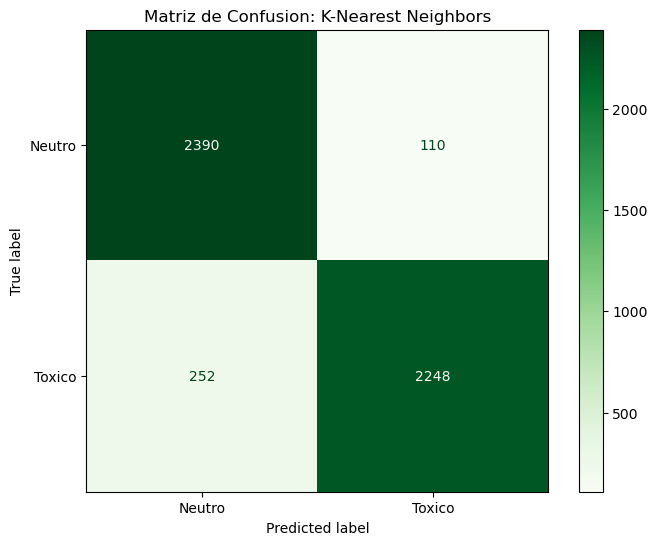


Mensaje: 'eres un bocachancla'
Prediccion: NEUTRO (Probabilidad de toxicidad: 0.4286)

Vecinos mas cercanos en el espacio TF-IDF:
1. NEUTRO | similitud coseno: 0.0000
2. TOXICO | similitud coseno: 0.0000
3. NEUTRO | similitud coseno: 0.0000
4. NEUTRO | similitud coseno: 0.0000
5. TOXICO | similitud coseno: 0.0000

Mensaje: 'muchas gracias por la ayuda'
Prediccion: NEUTRO (Probabilidad de toxicidad: 0.1350)

Vecinos mas cercanos en el espacio TF-IDF:
1. NEUTRO | similitud coseno: 0.6316
2. NEUTRO | similitud coseno: 0.4577
3. NEUTRO | similitud coseno: 0.4265
4. TOXICO | similitud coseno: 0.4092
5. NEUTRO | similitud coseno: 0.3653


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. CARGA DE DATOS (Dataset ya limpio con tu funcion preferida)
df = pd.read_csv('DATASET_LIMPIO_PARA_MODELOS.csv')
# Aseguramos que no haya valores nulos tras la limpieza
df = df.dropna(subset=['texto_limpio'])

# KNN puede ser lento porque compara cada ejemplo nuevo con muchos ejemplos de entrenamiento.
# Para mantenerlo rapido y entendible, usamos una muestra estratificada si el dataset es grande.
MAX_MENSAJES_KNN = 25000
if len(df) > MAX_MENSAJES_KNN:
    df = (
        df.groupby('toxicidad', group_keys=False)
          .apply(lambda x: x.sample(n=min(len(x), MAX_MENSAJES_KNN // 2), random_state=42))
          .sample(frac=1, random_state=42)
          .reset_index(drop=True)
    )

X = df['texto_limpio']
y = df['toxicidad']

# 2. REPRESENTACION DE DATOS: TF-IDF (Unidad 1)
# Convertimos texto en vectores numericos. Reducimos max_features para acelerar las distancias.
# Usamos unigramas y bigramas para conservar algo de contexto.
vectorizador = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = vectorizador.fit_transform(X)

# 3. DIVISION DEL DATASET (Unidad 1: Performance Assessment)
# Stratify mantiene una proporcion similar de mensajes neutros y toxicos en train/test.
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# 4. MODELO: K-Nearest Neighbors (Unidad 2)
# KNN no aprende una formula como Naive Bayes: guarda los ejemplos y busca los vecinos mas cercanos.
# metric='cosine' funciona bien con TF-IDF porque compara orientacion/similitud textual.
# algorithm='brute' es lo recomendado para matrices sparse como TF-IDF.
print(f"Entrenando KNN con {X_train.shape[0]} mensajes y {X_train.shape[1]} caracteristicas TF-IDF...")
modelo_knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
modelo_knn.fit(X_train, y_train)

# 5. EVALUACION (Unidad 1)
# La prediccion es la parte lenta en KNN, porque calcula vecinos para cada mensaje de test.
print("Prediciendo con KNN. Puede tardar un poco mas que Naive Bayes...")
y_pred = modelo_knn.predict(X_test)

print("\n" + "="*40)
print("REPORTE DE CLASIFICACION KNN (Metricas Unidad 1)")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['Neutro', 'Toxico']))

# 6. VISUALIZACION: MATRIZ DE CONFUSION (Unidad 1)
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutro', 'Toxico'])
disp.plot(cmap=plt.cm.Greens, ax=ax)
plt.title('Matriz de Confusion: K-Nearest Neighbors')
plt.savefig('matriz_confusion_knn.png') # Guardamos para tu TFG
plt.show()

# 7. PRUEBA ESPECIFICA (Caso "Bocachancla")
def test_mensaje(msg, mostrar_vecinos=True):
    # Nota: Aqui deberias aplicar la funcion limpieza_profunda antes de transformar
    # pero para una prueba rapida usamos el vectorizador directo:
    msg_vec = vectorizador.transform([msg])
    pred = modelo_knn.predict(msg_vec)
    prob = modelo_knn.predict_proba(msg_vec)
    clase = "TOXICO" if pred[0] == 1 else "NEUTRO"
    print(f"\nMensaje: '{msg}'")
    print(f"Prediccion: {clase} (Probabilidad de toxicidad: {prob[0][1]:.4f})")

    if mostrar_vecinos:
        distancias, indices = modelo_knn.kneighbors(msg_vec, n_neighbors=5)
        print("\nVecinos mas cercanos en el espacio TF-IDF:")
        for posicion, (distancia, indice) in enumerate(zip(distancias[0], indices[0]), start=1):
            etiqueta = "TOXICO" if y_train.iloc[indice] == 1 else "NEUTRO"
            similitud = 1 - distancia
            print(f"{posicion}. {etiqueta} | similitud coseno: {similitud:.4f}")

test_mensaje("eres un bocachancla")
test_mensaje("muchas gracias por la ayuda")

In [25]:
# Prueba adicional rapida
test_mensaje("buenos dias")


Mensaje: 'buenos dias'
Prediccion: TOXICO (Probabilidad de toxicidad: 0.8876)

Vecinos mas cercanos en el espacio TF-IDF:
1. TOXICO | similitud coseno: 0.6408
2. TOXICO | similitud coseno: 0.6329
3. TOXICO | similitud coseno: 0.5596
4. TOXICO | similitud coseno: 0.4434
5. TOXICO | similitud coseno: 0.4420
